Import statements

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Read the data

In [25]:
# Read the csv
data = pd.read_csv("telecom_churn.csv")
data.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


Check for nulls

In [3]:
data.isna().any()

Churn              False
AccountWeeks       False
ContractRenewal    False
DataPlan           False
DataUsage          False
CustServCalls      False
DayMins            False
DayCalls           False
MonthlyCharge      False
OverageFee         False
RoamMins           False
dtype: bool

Check for duplicates

In [4]:
data.duplicated().any()

np.False_

Descriptive stats

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [6]:
data.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [7]:
data.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

How many customers churned, and how many didn't?

In [8]:
df_churn = data.Churn.value_counts()
df_churn

Churn
0    2850
1     483
Name: count, dtype: int64

In [9]:
bar = px.bar(x=["No", "Yes"], y=df_churn.values, title="Churn Count")
bar.show()

# How do the customer attributes affect the churn rate?

Relationship between churn and contract renewal

In [26]:
# Churn rate by contract renewal
churn_rate = data.groupby("ContractRenewal")["Churn"].mean()

# Plot
bar = px.bar(x=["No", "Yes"], y=churn_rate.values, color=churn_rate.values, 
             color_continuous_scale=px.colors.sequential.haline,
             title="Churn Rate by Contract Renewal")
bar.update_layout(xaxis_title="Contract Renewal", 
                  yaxis_title="Churn Rate",
                  coloraxis_showscale=False)
bar.show()

Relationship between churn and Data plan

In [13]:
churn_dataplan_rate = data.groupby("DataPlan")["Churn"].mean()

data_bar = px.bar(x=["No", "Yes"], y=churn_dataplan_rate.values, color=churn_dataplan_rate.values, 
             color_continuous_scale=px.colors.sequential.haline,
             title="Churn Rate by Data Plan")
data_bar.update_layout(xaxis_title="Data Plan", 
                  yaxis_title="Churn Rate",
                  coloraxis_showscale=False)
data_bar.show()

Relationship between churn and monthly charge

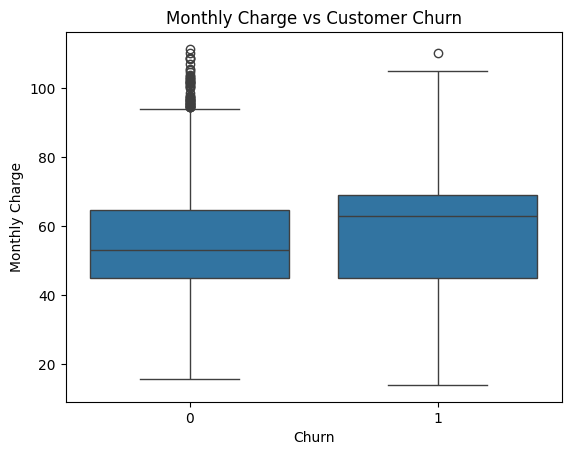

In [14]:
sns.boxplot(data=data, x="Churn", y="MonthlyCharge")
plt.title("Monthly Charge vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charge")
plt.show()

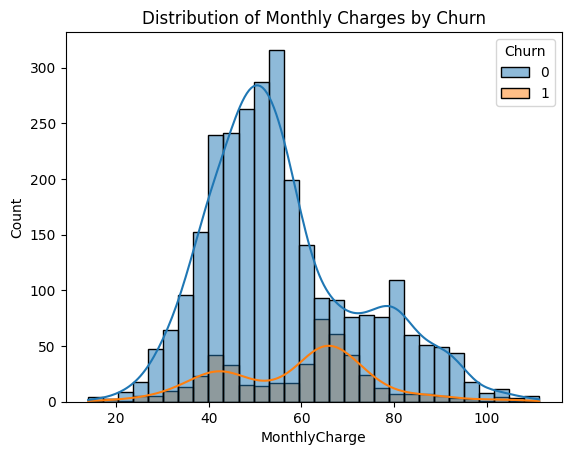

In [15]:
sns.histplot(data=data, x="MonthlyCharge", hue="Churn", bins=30, kde=True)
plt.title("Distribution of Monthly Charges by Churn")
plt.show()

Churn rate per monthly charge band

In [16]:
# Create price bands
data["ChargeBand"] = pd.qcut(data["MonthlyCharge"], q=4)
# Calculate the churn rate per band
churn_by_band = data.groupby("ChargeBand")["Churn"].mean()

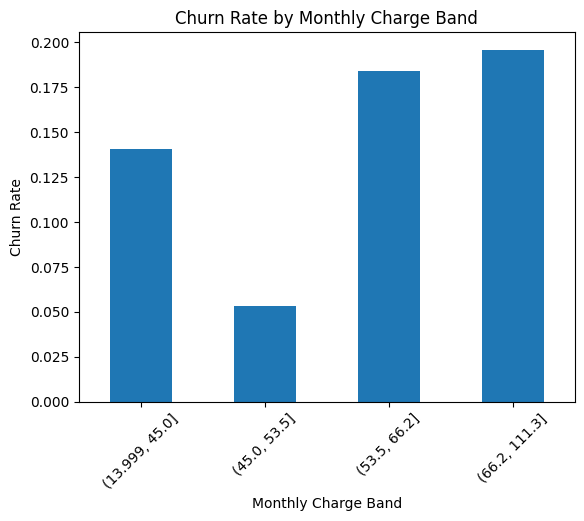

In [17]:
# Visualize the churn rate per charge band
churn_by_band.plot(kind="bar")
plt.title("Churn Rate by Monthly Charge Band")
plt.xlabel("Monthly Charge Band")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.show()

Relationship between churn and Overage fee

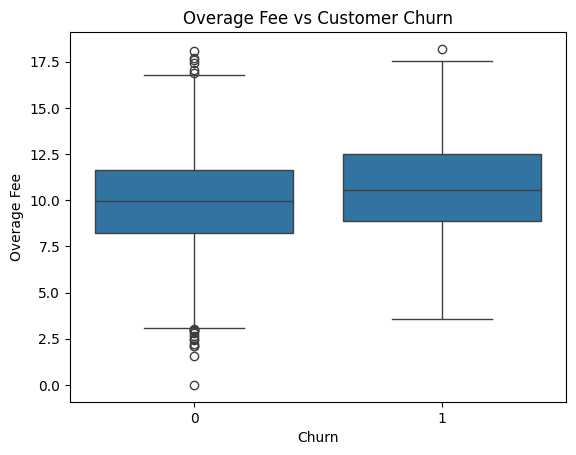

In [18]:
sns.boxplot(data=data, x="Churn", y="OverageFee")
plt.title("Overage Fee vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Overage Fee")
plt.show()

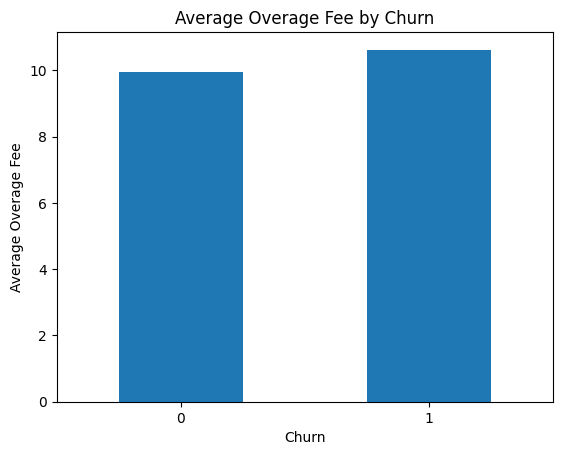

In [19]:
data.groupby("Churn")["OverageFee"].mean().plot(kind="bar")
plt.title("Average Overage Fee by Churn")
plt.ylabel("Average Overage Fee")
plt.xticks(rotation = 0)
plt.show()

Heatmap: Overage Fee vs Customer Service Calls vs Churn

In [20]:
# Creating Overage Fee bands
data["OverageBand"] = pd.qcut(data["OverageFee"], q=4)

In [21]:
#Create a pivot table
pivot = data.pivot_table(values="Churn",
                         index="CustServCalls",
                         columns="OverageBand",
                         aggfunc="mean")

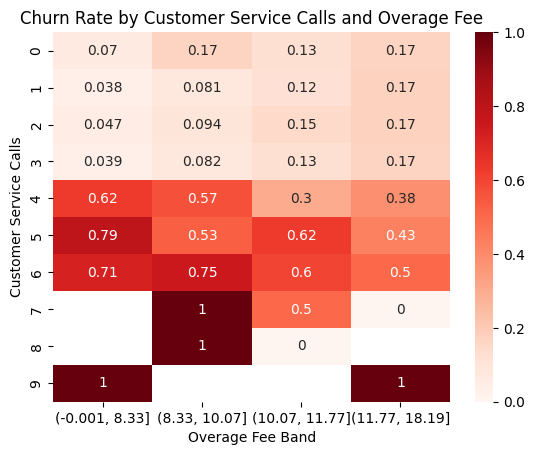

In [22]:
# Heatmap
sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Churn Rate by Customer Service Calls and Overage Fee")
plt.xlabel("Overage Fee Band")
plt.ylabel("Customer Service Calls")

plt.show()

Relationship between customer churn and customer service calls

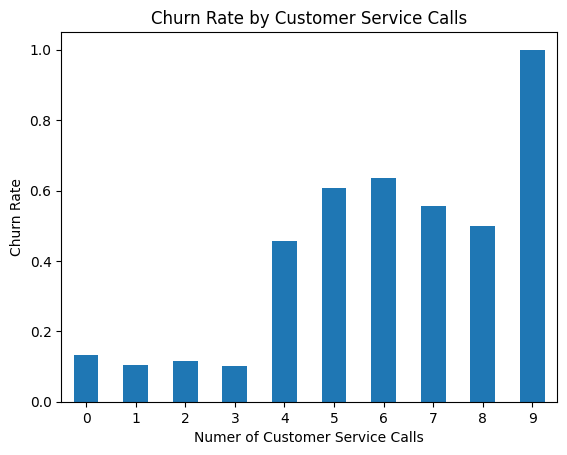

In [23]:
# Calculate churn rate per number of calls
churn_calls = data.groupby("CustServCalls")["Churn"].mean()

churn_calls.plot(kind="bar")
plt.title("Churn Rate by Customer Service Calls")
plt.xlabel("Numer of Customer Service Calls")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

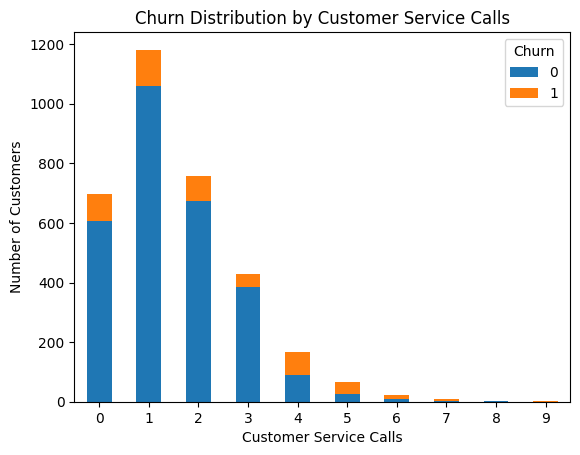

In [24]:
pd.crosstab(data["CustServCalls"], data["Churn"]).plot(kind="bar", stacked=True)
plt.title("Churn Distribution by Customer Service Calls")
plt.xlabel("Customer Service Calls")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

Correlation between attributes and churn

In [10]:
# Select the numeric columns only
num_df = data.select_dtypes(include=["int64", "float64"])
# Calculate the correlation
corr_matrix = num_df.corr()
corr_matrix["Churn"].sort_values(ascending=False)

Churn              1.000000
CustServCalls      0.208750
DayMins            0.205151
OverageFee         0.092812
MonthlyCharge      0.072313
RoamMins           0.068239
DayCalls           0.018459
AccountWeeks       0.016541
DataUsage         -0.087195
DataPlan          -0.102148
ContractRenewal   -0.259852
Name: Churn, dtype: float64

Correlation heatmap

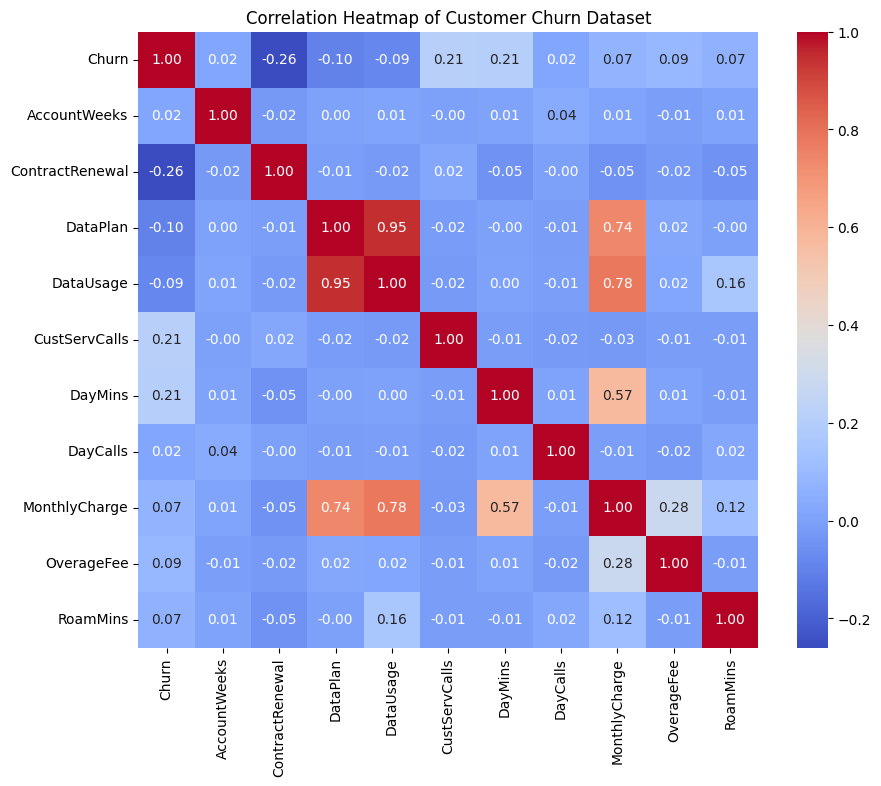

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Customer Churn Dataset")
plt.show()